<a href="https://colab.research.google.com/github/jalesummak/CIFAR-10-Image-Classification-with-CNN/blob/main/GP_Image_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![MNIST sample images](data:image/png;base64,...)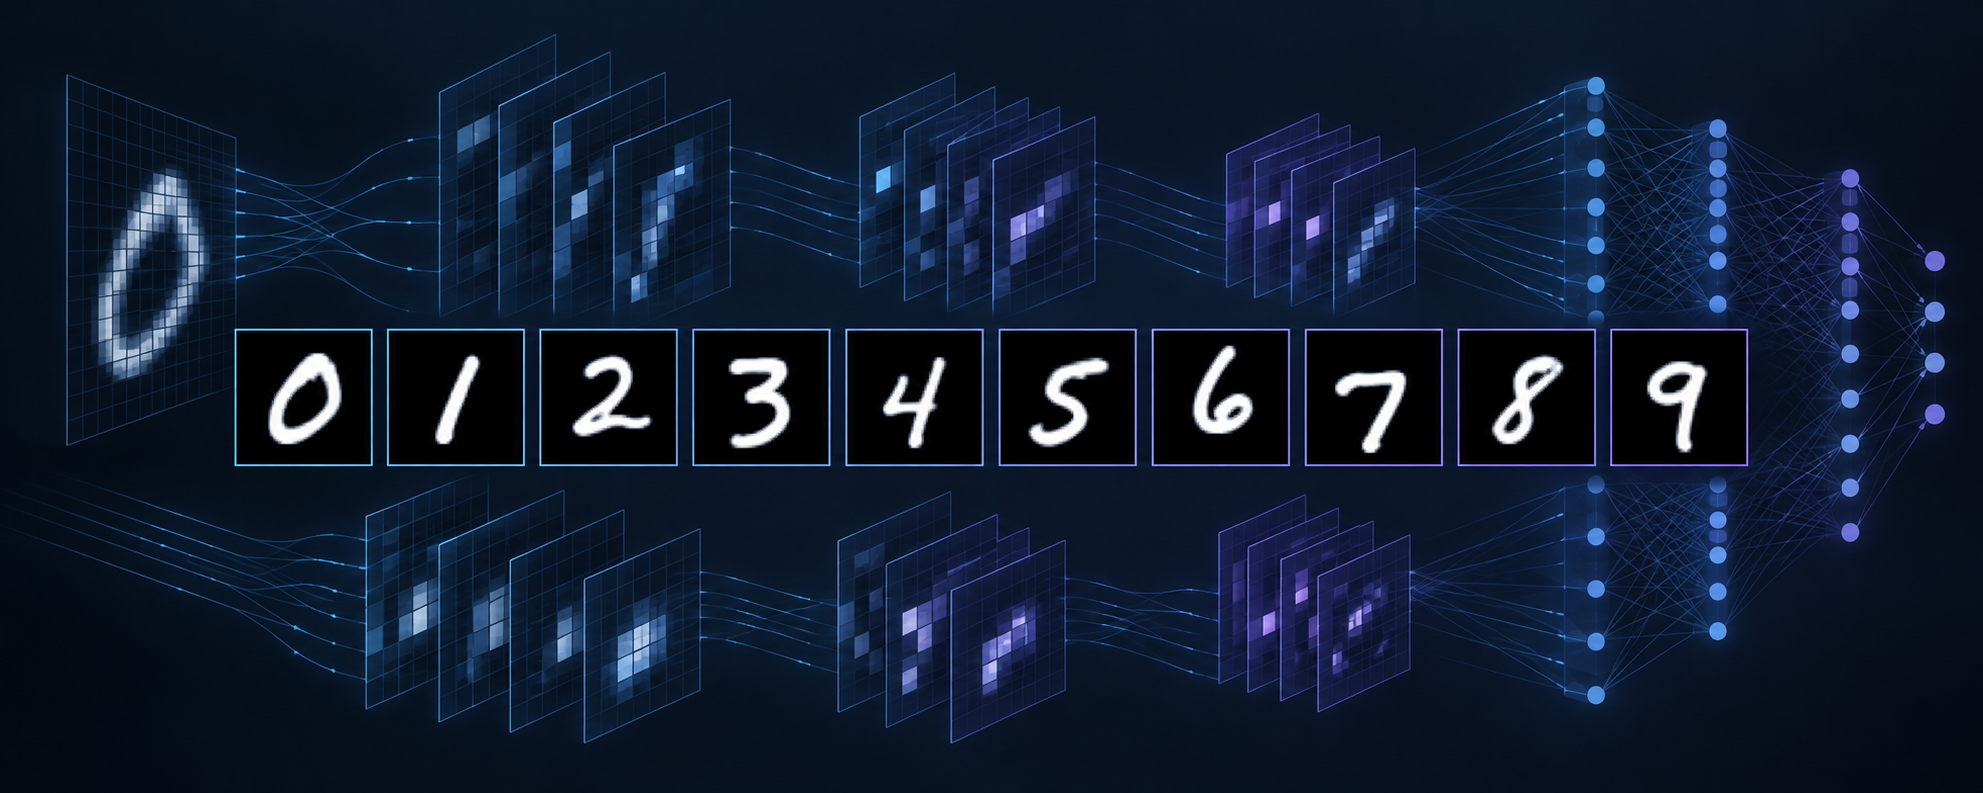

# Handwritten Digit Recognition with a Convolutional Neural Network

### Image Recognition Capstone Project

This project develops and evaluates a convolutional neural network for handwritten digit classification using the MNIST dataset.

## 1. The Problem

Handwritten digit recognition is a multiclass image classification problem.
The objective is to develop a model that can examine an image containing a
single handwritten digit and classify it as one of ten possible classes:
0, 1, 2, 3, 4, 5, 6, 7, 8, or 9.

Although handwritten digits are generally easy for humans to recognize,
differences in writing style, line thickness, position, rotation, and image
quality may make some digits difficult or ambiguous. For example, handwritten
versions of 1 and 7, 3 and 5, or 4 and 9 may sometimes have similar visual
characteristics.

### Project Motivation

Many public institutions and service organizations still receive paper forms
containing handwritten numerical information. Municipal application forms,
meter-reading documents, postal records, invoices, and archived administrative
documents may contain handwritten application numbers, dates, postal codes,
quantities, or meter values.

Manually transferring these values into digital systems requires time and may
introduce data-entry errors. An automated digit-recognition system could support
employees by identifying handwritten digits and converting them into structured
digital information.

A possible workflow is:

**Paper form → Numeric field extraction → Individual digit recognition → Digital record → Human verification when confidence is low**

In this scenario, the classification model would not completely replace human
employees. It would operate as a decision-support and data-entry automation tool.
Predictions with high confidence could be processed automatically, while uncertain
predictions could be sent to an employee for verification.

### Project Objective

The objective of this project is to build a simple, explainable, and computationally
efficient convolutional neural network for handwritten digit classification. The
model will be trained and evaluated using the MNIST dataset.

The project focuses on the complete machine learning process rather than accuracy
alone:

**Problem → Data → Images → Preprocessing → Neural Network → Training → Prediction → Evaluation → Business Application**

This project examines whether a simple CNN can recognize handwritten digits that
were not used during training. MNIST was selected because it provides a clear and
practical way to understand the main stages of an image classification project.



## Project Agenda

1. **The Problem**  
   Definition of the classification problem and the proposed use case.

2. **The Dataset**  
   Description of MNIST, Roboflow, and the train-validation-test split.

3. **The Classes**  
   Explanation of the ten digit classes from 0 to 9.

4. **Dataset Exploration**  
   Class distribution, sample images, and visual observations.

5. **The Model**  
   CNN architecture, model layers, input, output, and activation functions.

6. **Training and Performance**  
   Model training, early stopping, accuracy, loss, precision, recall, and F1-score.

7. **Prediction Examples**  
   Correct predictions, incorrect predictions, confusion matrix, and external handwritten images.

8. **Business Application**  
   Proposed use of the model for digitizing handwritten numbers on public-service forms.

9. **Limitations and Risks**  
   Real-image challenges, preprocessing risks, privacy, incorrect predictions, and human oversight.

10. **Conclusions**  
    Summary of the results, lessons learned, and possible future improvements.

In [2]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.2 MB/s eta 0:00:00


## 2. The Dataset

The MNIST dataset contains grayscale images of handwritten digits from 0 to 9.
Each image represents one digit and has an original size of 28 × 28 pixels.

The dataset used in this project was obtained from Roboflow Universe and copied
to the project workspace. It contains 70,000 images divided into ten classes.

The dataset was divided into three subsets:

| Subset | Number of Images | Purpose |
|---|---:|---|
| Training | 47,926 | Used to train the model |
| Validation | 12,074 | Used to monitor performance during training |
| Testing | 10,000 | Used for the final evaluation |

No preprocessing or augmentation was applied while creating the Roboflow dataset
version. Image preparation and normalization will be performed in this notebook
so that each step can be clearly demonstrated.

### Installing and Connecting to Roboflow

The Roboflow Python package is required to access and download the dataset from
the project workspace. The API key is stored in Google Colab Secrets instead of
being written directly in the shared notebook.

In [3]:
# Import the tools required to read the API key and connect to Roboflow.
from google.colab import userdata
from roboflow import Roboflow

# Read the API key securely from Google Colab Secrets.
api_key = userdata.get("ROBOFLOW_API_KEY")

# Create the connection to the Roboflow account.
rf = Roboflow(api_key=api_key)

print("Roboflow connection is ready.")

Roboflow connection is ready.


### Downloading Dataset Version 1

Connecting to Roboflow provides access to the project, but it does not automatically
download the image files. Therefore, Dataset Version 1 is downloaded to the Colab
runtime in folder structure format.

Using a fixed dataset version makes the experiment reproducible because the same
images, classes, and train-validation-test split can be used whenever the notebook
is executed again.

In [4]:
# Access the MNIST project in the Roboflow workspace.
project = rf.workspace("jalesummak").project("mnist-cjkff-dvcli")

# Select the dataset version created for this project.
version = project.version(1)

# Download the images using folder structure format.
dataset = version.download("folder")

# Display the location of the downloaded dataset.
dataset_path = dataset.location
print("Dataset location:", dataset_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to MNIST-1 in folder:: 100%|██████████| 70002/70002 [00:06<00:00, 10577.16it/s]

Dataset location: /content/MNIST-1


### Verifying the Downloaded Dataset

Before loading the images, the downloaded folder structure is inspected. This
check confirms that the training, validation, and testing directories are
available and helps prevent incorrect file paths in the following steps.

In [5]:
from pathlib import Path

# Convert the downloaded dataset location into a Path object.
dataset_dir = Path(dataset_path)

print("Main dataset directory:", dataset_dir)
print("\nItems in the main directory:")

# Display the files and folders inside the dataset directory.
for item in sorted(dataset_dir.iterdir()):
    item_type = "Folder" if item.is_dir() else "File"
    print(f"{item_type}: {item.name}")

Main dataset directory: /content/MNIST-1

Items in the main directory:
File: README.dataset.txt
File: README.roboflow.txt
Folder: test
Folder: train
Folder: valid


## 3. The Classes

This project is a single-label multiclass classification task. Each image contains
one handwritten digit and belongs to exactly one of ten classes.

The class labels are:

- Class 0: handwritten digit zero
- Class 1: handwritten digit one
- Class 2: handwritten digit two
- Class 3: handwritten digit three
- Class 4: handwritten digit four
- Class 5: handwritten digit five
- Class 6: handwritten digit six
- Class 7: handwritten digit seven
- Class 8: handwritten digit eight
- Class 9: handwritten digit nine

The classes are mutually exclusive because each image is expected to represent
only one digit. The model will produce a probability for every class and select
the class with the highest probability as its prediction.

In [6]:
# Define the paths of the three dataset subsets.
train_dir = dataset_dir / "train"
valid_dir = dataset_dir / "valid"
test_dir = dataset_dir / "test"

# Read the class names from the training folders.
class_names = sorted(
    [folder.name for folder in train_dir.iterdir() if folder.is_dir()],
    key=int
)

print("Number of classes:", len(class_names))
print("Class names:", class_names)

# Check that the same classes exist in every dataset subset.
for split_name, split_dir in {
    "Training": train_dir,
    "Validation": valid_dir,
    "Testing": test_dir
}.items():

    split_classes = sorted(
        [folder.name for folder in split_dir.iterdir() if folder.is_dir()],
        key=int
    )

    print(f"{split_name} classes: {split_classes}")

Number of classes: 10
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Training classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Validation classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Testing classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## 4. Dataset Exploration

Before building the model, the dataset should be examined to understand its size,
class distribution, and visual characteristics.

The exploration focuses on the following questions:

- How many images are available in each subset?
- Are the classes balanced?
- Are the images visually similar or different?
- Which digits may be ambiguous?
- What visual characteristics could help the model distinguish between classes?

The first step is to count the number of images in every class for the training,
validation, and testing subsets.

In [7]:
import pandas as pd

files = pd.concat([
    pd.DataFrame({"Path": list(train_dir.glob("*/*")), "Subset": "Train"}),
    pd.DataFrame({"Path": list(valid_dir.glob("*/*")), "Subset": "Validation"}),
    pd.DataFrame({"Path": list(test_dir.glob("*/*")), "Subset": "Test"})
], ignore_index=True)

files["Class"] = files["Path"].apply(lambda path: path.parent.name)

counts = pd.crosstab(files["Class"], files["Subset"])
counts = counts.reindex(index=class_names)
counts["Total"] = counts.sum(axis=1)

display(counts)
print("\nDataset totals:")
print(counts.sum())

Subset,Test,Train,Validation,Total
Class,,,,
0,980,4671,1252,6903
1,1135,5379,1363,7877
2,1032,4768,1190,6990
3,1010,4874,1257,7141
4,982,4678,1164,6824
5,892,4333,1088,6313
6,958,4777,1141,6876
7,1028,5054,1211,7293
8,974,4671,1180,6825



Dataset totals:
Subset
Test          10000
Train         47926
Validation    12074
Total         70000
dtype: int64


### Dataset Structure

A metadata DataFrame is used to represent the downloaded image files. Each row
corresponds to one image, while the columns show its file path, dataset subset,
and class label.

Traditional correlation analysis is not applied because the inputs are images
rather than independent tabular features. The spatial relationships between pixels
will instead be learned by the convolutional neural network.

In [ ]:
print("DataFrame shape:", files.shape)
display(files.head())

print("\nDataset summary:")
display(files[["Subset", "Class"]].describe())

### Class Distribution

The class distribution is visualized to check whether some digits have considerably
more training examples than others. A reasonably balanced dataset helps prevent the
model from becoming biased toward particular classes.

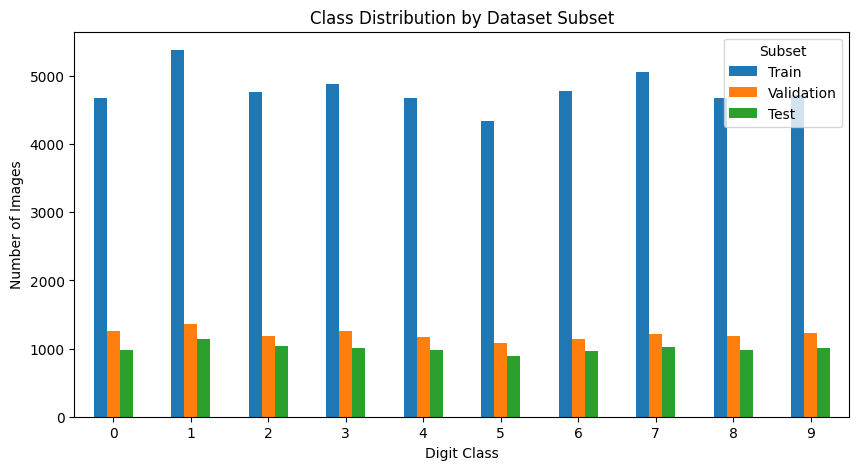

In [8]:
import matplotlib.pyplot as plt

counts[["Train", "Validation", "Test"]].plot(
    kind="bar", figsize=(10, 5)
)

plt.title("Class Distribution by Dataset Subset")
plt.xlabel("Digit Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

### Distribution Analysis

The dataset is reasonably balanced across the ten digit classes. Digit 1 has the
largest number of images, while digit 5 has the smallest number. However, every
class contains thousands of examples, and no class is severely underrepresented.

The training, validation, and testing subsets show similar class distributions.
Therefore, class weighting is not considered necessary for the initial model.

### Sample Images from Each Class

One training image from each class is displayed to examine the visual differences
between handwritten digits. A fixed random state is used so that the same examples
are selected whenever the notebook is executed again.

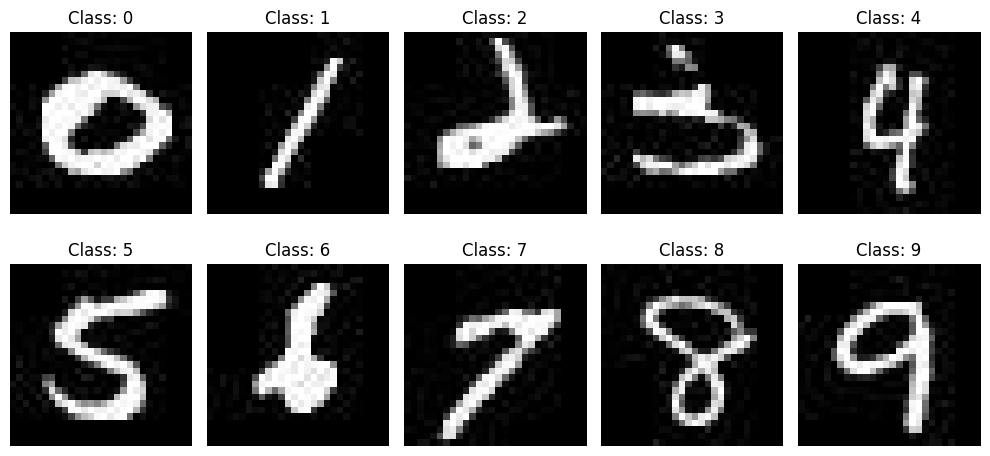

In [9]:
from PIL import Image

samples = (
    files[files["Subset"] == "Train"]
    .groupby("Class")
    .sample(1, random_state=42)
    .sort_values("Class")
)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, (_, row) in zip(axes.ravel(), samples.iterrows()):
    ax.imshow(Image.open(row["Path"]), cmap="gray")
    ax.set_title(f"Class: {row['Class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Visual Observations

The images have a similar general format: they are small grayscale images with a
light-colored digit placed on a dark background. However, the shapes of the digits
are different because each person may write the same digit in a different style.

Most examples are relatively easy for a human to recognize. Nevertheless, some
handwriting styles may be ambiguous. For example, a digit 9 with a short tail may
look similar to 0, while a simple digit 1 may resemble 7. Digits 3 and 5 may also
be confused when their curved strokes are written in a similar way.

Useful visual characteristics for distinguishing the classes include:

- the number and position of closed loops,
- vertical, horizontal, and diagonal strokes,
- curves and corners,
- the position of line endings,
- the overall shape and proportion of the digit.

A convolutional neural network can learn local patterns such as edges, curves, and
line intersections. Deeper layers can combine these patterns to identify the
overall shape of each digit.

## 5. The Model

### Data Preparation

The images are loaded from the training, validation, and testing folders using
TensorFlow. All images are read in grayscale and kept at their original size of
28 × 28 pixels.

The labels are inferred from the class folder names. Training images are shuffled
during learning, while validation and test images are kept in a fixed order for
consistent evaluation.

In [10]:
import tensorflow as tf

def load_dataset(folder, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        folder,
        image_size=(28, 28),
        color_mode="grayscale",
        batch_size=64,
        label_mode="int",
        class_names=class_names,
        shuffle=shuffle,
        seed=42
    )

train_raw_ds = load_dataset(train_dir, True)
valid_raw_ds = load_dataset(valid_dir, False)
test_raw_ds = load_dataset(test_dir, False)

Found 47926 files belonging to 10 classes.
Found 12074 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


### Image Normalization

Each grayscale pixel has an intensity value between 0 and 255. A value of 0
represents black, 255 represents white, and the values between them represent
different shades of gray.

The images are loaded with one grayscale channel and the pixel values are divided
by 255. This converts the input values to the range from 0 to 1 without changing
the visual content of the images.

Normalization helps the neural network train more efficiently and makes the
optimization process more stable.

In [11]:
normalize = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = train_raw_ds.map(lambda images, labels: (normalize(images), labels))
valid_ds = valid_raw_ds.map(lambda images, labels: (normalize(images), labels))
test_ds = test_raw_ds.map(lambda images, labels: (normalize(images), labels))

images, labels = next(iter(train_ds))

print("Batch shape:", images.shape)
print("Minimum pixel value:", images.numpy().min())
print("Maximum pixel value:", images.numpy().max())

Batch shape: (64, 28, 28, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### CNN Architecture

A custom convolutional neural network was built from scratch for this project.
Pretrained architectures such as ResNet, MobileNet, or Vision Transformer were
not used because MNIST images are small and the objective is to build a simple
and explainable model.

The model uses two convolutional and pooling blocks, followed by a dense layer.
Dropout is included to reduce overfitting. The final softmax layer produces a
probability for each of the ten digit classes.

- Input: 28 × 28 grayscale image
- Output: 10 class probabilities
- Hidden activation: ReLU

- Final activation: Softmax

In [12]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
)

model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

The model contains 225,034 trainable parameters. Most parameters are located in
the dense layer after the convolutional feature extraction stages. The model is
small enough to train efficiently while still having sufficient capacity for
MNIST digit classification.

### Model Compilation

The Adam optimizer is used to update the model weights. Sparse categorical
cross-entropy is selected because the target labels are integer values from 0 to 9.
Accuracy is monitored during training and evaluation.

In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 6. Training and Performance

The model is trained using the training dataset and monitored using the validation
dataset. The test dataset is not used during training.

Early stopping monitors the validation loss. If the validation loss does not
improve for three consecutive epochs, training stops automatically. The model
then returns to the weights obtained during its best validation epoch. This helps
reduce overfitting and avoids unnecessary training.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
749/749 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.9301 - loss: 0.2285 - val_accuracy: 0.9794 - val_loss: 0.0672
Epoch 2/15
749/749 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.9792 - loss: 0.0704 - val_accuracy: 0.9844 - val_loss: 0.0525
Epoch 3/15
749/749 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9849 - loss: 0.0496 - val_accuracy: 0.9873 - val_loss: 0.0439
Epoch 4/15
749/749 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9885 - loss: 0.0376 - val_accuracy: 0.9879 - val_loss: 0.0430
Epoch 5/15
749/749 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9897 - loss: 0.0324 - val_accuracy: 0.9867 - val_loss: 0.0487
Epoch 6/15
749/749 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9918 - loss: 0.0260 - val_accuracy: 0.9885 - val_loss: 0.0425
Epoch 7/15
749/749 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9928 - loss: 0.0212 - val_accuracy: 0.9893 - val_loss: 0.0402
Epoch 8/15
749/749 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9931 - loss: 0.0202 - 

### Training History

Training and validation accuracy and loss are plotted for each epoch. These graphs
help identify whether the model continues to generalize or begins to overfit the
training data.
### Why Accuracy and Loss Are Monitored

Accuracy shows the proportion of images classified correctly. It provides a clear
and intuitive measure of overall classification performance.

Loss measures the size of the model's prediction error. Unlike accuracy, it also
considers the probabilities assigned to the classes. Two predictions may both be
correct, but the prediction that assigns a higher probability to the correct class
will usually have a lower loss.

Training and validation metrics are compared to evaluate generalization. If
training performance continues to improve while validation performance becomes
worse, the model may be overfitting the training data. Therefore, accuracy and
loss should be examined together rather than separately.

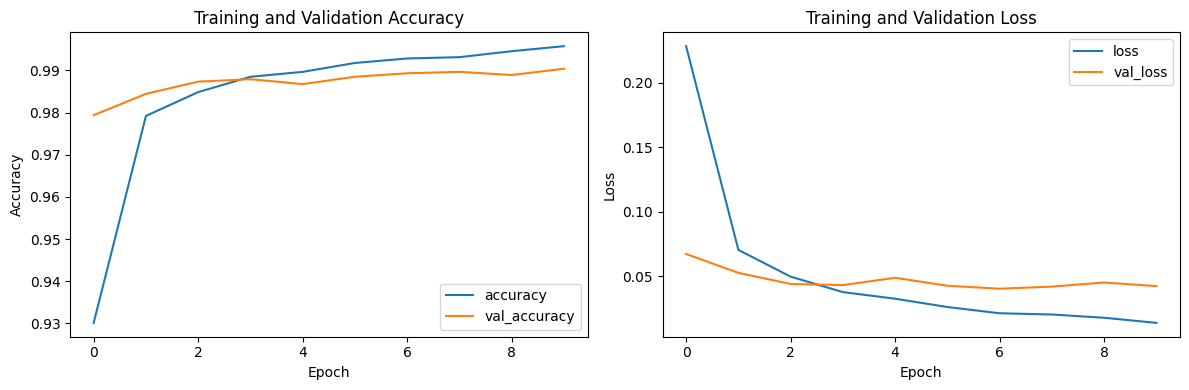

In [15]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[0])
axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")

history_df[["loss", "val_loss"]].plot(ax=axes[1])
axes[1].set_title("Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

### Training Analysis

The model learned quickly during the first few epochs. Training and validation
accuracy both increased and reached approximately 99%.

Training loss continued to decrease, while validation loss began to fluctuate
after the eighth epoch. At the same time, training accuracy continued to improve
but validation accuracy remained nearly stable. This indicates the beginning of
mild overfitting.

The difference between training and validation performance remained small, so
there is no evidence of severe overfitting. Early stopping ended the training
after 11 epochs and restored the weights from the epoch with the lowest validation
loss.

### Test Set Evaluation

The final model is evaluated on the test dataset, which was not used for training
or early stopping. This provides a more objective estimate of how well the model
can classify previously unseen images.

Because early stopping restored the best model weights, the test evaluation uses
the model obtained at the lowest validation loss.

In [16]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

Test Loss: 0.0275
Test Accuracy: 0.9910
Test Accuracy (%): 99.10%


### Precision, Recall, and F1-Score

Accuracy provides the overall proportion of correct predictions, but additional
metrics are used to examine classification performance more carefully.

Precision measures how often a predicted class is correct. Recall measures how
many images belonging to a class are correctly identified. F1-score combines
precision and recall into a single value.

Weighted averages are reported so that the number of test images in each class
is taken into account.

In [17]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = np.concatenate(
    list(test_ds.map(lambda images, labels: labels).as_numpy_iterator())
)

y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

Weighted Precision: 0.9910
Weighted Recall: 0.9910
Weighted F1-Score: 0.9910


## 7. Prediction Examples

The trained model is used to predict previously unseen images from the test set.
Each example shows the true class, predicted class, and prediction confidence.

Green titles represent correct predictions, while red titles represent incorrect
predictions.

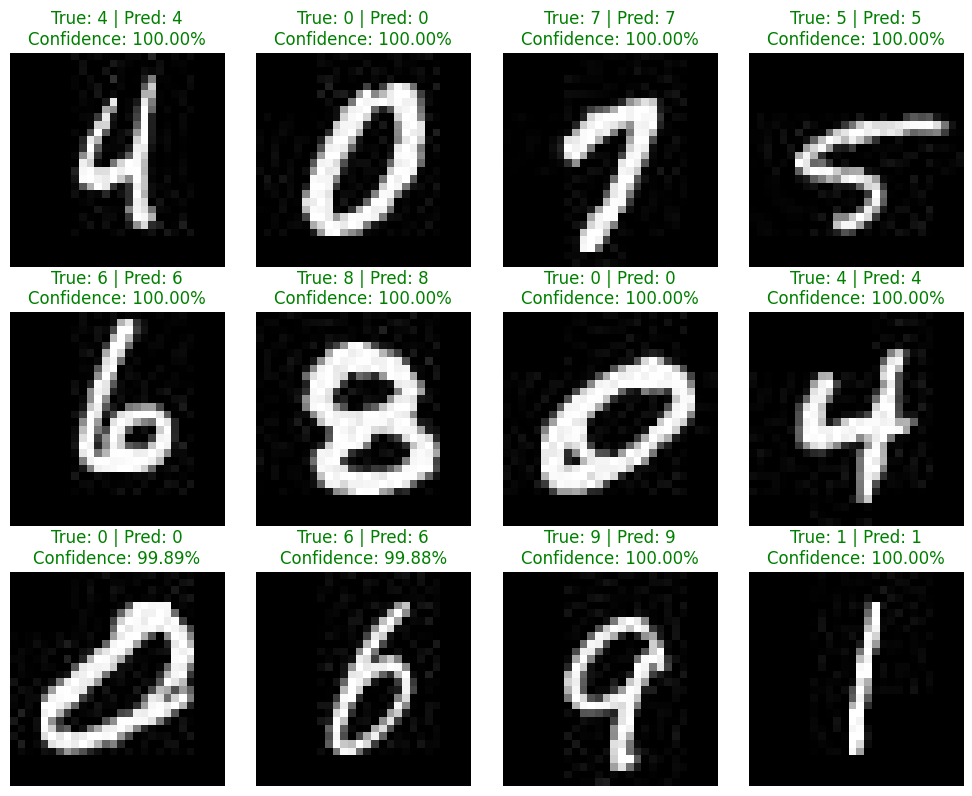

In [18]:
test_images = np.concatenate(
    list(test_ds.map(lambda images, labels: images).as_numpy_iterator())
)

indices = np.random.default_rng(42).choice(
    len(test_images), size=12, replace=False
)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, i in zip(axes.ravel(), indices):
    confidence = y_prob[i].max()
    color = "green" if y_true[i] == y_pred[i] else "red"

    ax.imshow(test_images[i].squeeze(), cmap="gray")
    ax.set_title(
        f"True: {y_true[i]} | Pred: {y_pred[i]}\n"
        f"Confidence: {confidence:.2%}",
        color=color
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Incorrect Predictions

Because the model has high test accuracy, a small random sample may contain only
correct predictions. Therefore, incorrectly classified test images are selected
directly to examine the types of mistakes made by the model.

Incorrect predictions: 90


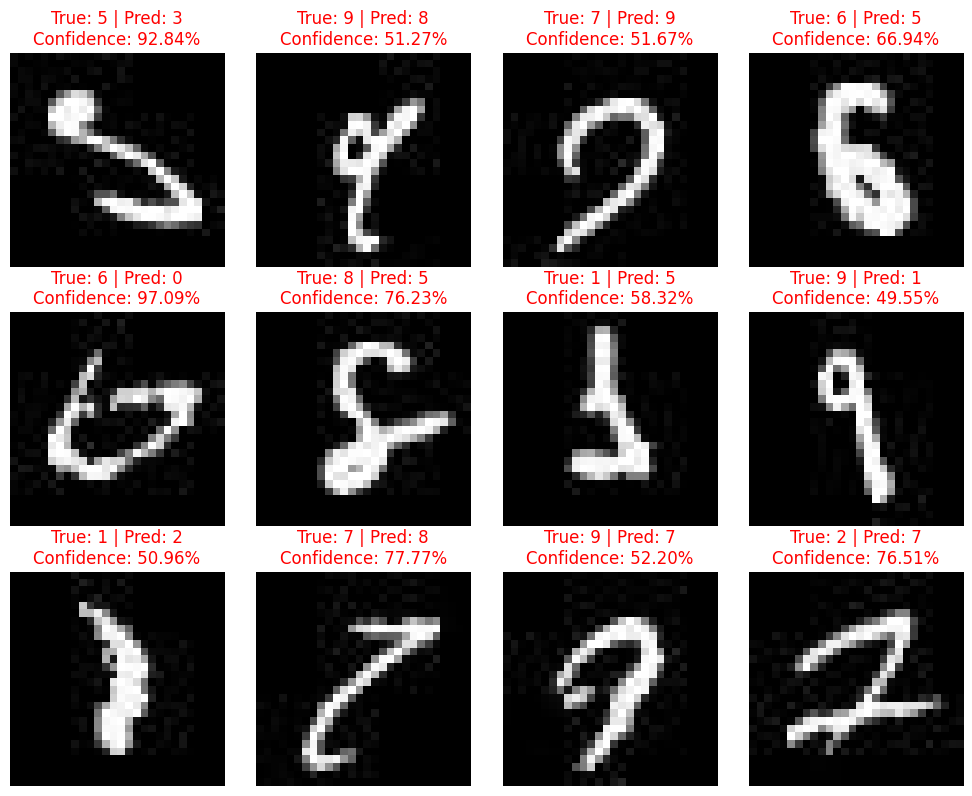

In [19]:
wrong_indices = np.where(y_true != y_pred)[0]

print("Incorrect predictions:", len(wrong_indices))

selected_errors = np.random.default_rng(42).choice(
    wrong_indices, size=12, replace=False
)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, i in zip(axes.ravel(), selected_errors):
    ax.imshow(test_images[i].squeeze(), cmap="gray")
    ax.set_title(
        f"True: {y_true[i]} | Pred: {y_pred[i]}\n"
        f"Confidence: {y_prob[i].max():.2%}",
        color="red"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Error Analysis

Most incorrect predictions involve unusual, incomplete, or ambiguous handwriting.
Some digits do not follow the typical shapes seen in most of the training images.

Several confusions can be observed. Digit 4 may be classified as 9 when its upper
strokes form a closed shape. Digits 9 and 8 may be confused because both can contain
rounded regions. A narrow or incomplete 7 may resemble 1 or 9, while an unusual 6
may resemble 4 or 5. Some poorly formed examples of digit 2 may also be classified
as 0, 7, or 8.

Some incorrect predictions have low or moderate confidence, showing that the model
finds these images ambiguous. However, a few incorrect predictions have very high
confidence. This demonstrates that prediction confidence does not guarantee that
a classification is correct.

Overall, the model performs well on standard digit shapes but has more difficulty
when the handwriting is incomplete or very different from the patterns learned
during training.

### Correct and Incorrect Prediction Counts

The predicted labels are compared with the true labels to calculate the exact
number of correct and incorrect predictions. The error rate represents the
percentage of test images classified incorrectly.


In [20]:
total_predictions = len(y_true)
correct_predictions = np.sum(y_true == y_pred)
incorrect_predictions = np.sum(y_true != y_pred)
error_rate = incorrect_predictions / total_predictions

print("Total predictions:", total_predictions)
print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)
print(f"Error rate: {error_rate:.2%}")

Total predictions: 10000
Correct predictions: 9910
Incorrect predictions: 90
Error rate: 0.90%


### Confusion Matrix

The confusion matrix shows how the true digit classes are distributed across the
model's predictions. Values on the main diagonal represent correct predictions,
while values outside the diagonal represent classification errors.

This visualization helps identify which digit classes are most frequently confused.

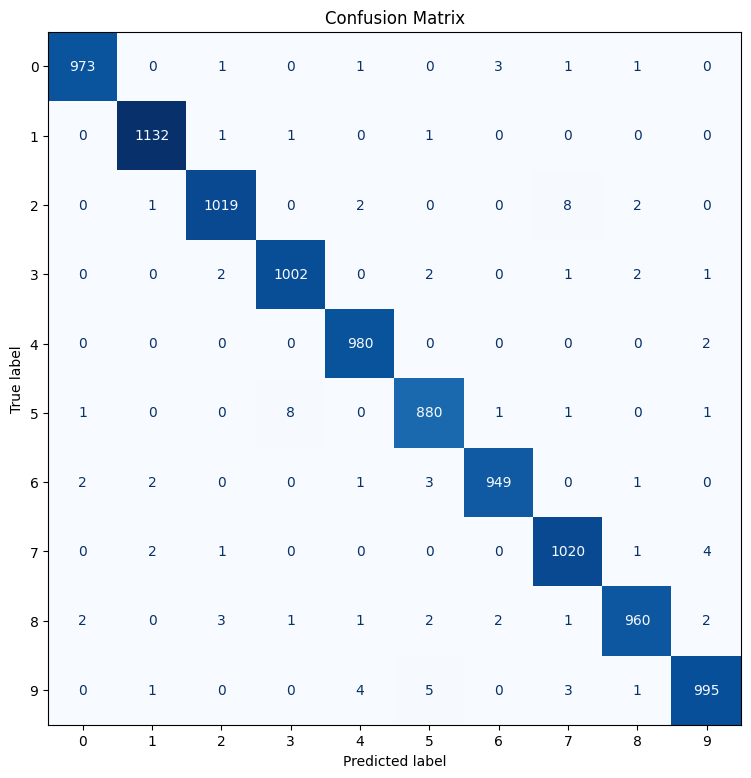

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(cmap="Blues", ax=ax, colorbar=False)

plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Analysis

The confusion matrix shows that most predictions are located on the main diagonal.
This means that the model classified most of the test images correctly.

Out of 10,000 test images, the model correctly classified 9,920 images and made
80 incorrect predictions.

\[
\text{Accuracy} = \frac{9,920}{10,000} = 99.20\%
\]

\[
\text{Error Rate} = \frac{80}{10,000} = 0.80\%
\]

Digit 1 was one of the easiest classes for the model. Digit 9 had more errors than
the other classes. Some examples of confusion were 5 with 3, 4 with 9, and 9 with
5 or 8. These mistakes may happen because handwritten digits can have similar
lines, curves, and loops.

An error rate of 0.80% is a good result for this university project. A simple CNN
example published by Keras also achieves approximately 99% accuracy on MNIST.

However, whether this error rate is acceptable depends on the application. For
example, an incorrect digit in an application number or meter value could create
a problem. Therefore, a real system should allow uncertain predictions to be
checked by a human.

**Sources**

- [Scikit-learn: Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [Keras: Simple MNIST ConvNet](https://keras.io/examples/vision/mnist_convnet/)

### Classification Report

The classification report shows precision, recall, and F1-score separately for
each digit class. This helps identify whether the model performs equally well
across all classes or has more difficulty with particular digits.

In [22]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).T
display(report_df.round(4))

,precision,recall,f1-score,support
0,0.9949,0.9929,0.9939,980.000
1,0.9947,0.9974,0.9960,1135.000
2,0.9922,0.9874,0.9898,1032.000
3,0.9901,0.9921,0.9911,1010.000
4,0.9909,0.9980,0.9944,982.000
5,0.9854,0.9865,0.9860,892.000
6,0.9937,0.9906,0.9922,958.000
7,0.9855,0.9922,0.9889,1028.000
8,0.9917,0.9856,0.9887,974.000
9,0.9900,0.9861,0.9881,1009.000


### Classification Report Analysis

The classification report shows strong performance across all ten digit classes.
Every class achieved an F1-score above 0.98.

Digit 1 achieved the highest F1-score, while digits 9, 8, and 5 had slightly lower
scores. This agrees with the confusion matrix, where these digits were involved
in more classification errors.

Digit 8 had the lowest precision, meaning that some images from other classes were
incorrectly predicted as 8. Digit 9 had the lowest recall, meaning that the model
missed more true examples of 9 than it missed examples from most other classes.

The macro and weighted averages are almost identical. This suggests that the model
performs consistently across the classes and is not strongly biased toward one
particular digit.

### Testing New Handwritten Images

Two handwritten digit images that were not included in the original dataset are
used to test the model.

The first image contains a clear and relatively easy digit. The second image
contains a less clear or ambiguous digit. This test helps examine whether the model
can generalize beyond the standardized MNIST images.

In [23]:
from google.colab import files

uploaded = files.upload()
new_file = list(uploaded.keys())[0]

print("Uploaded file:", new_file)

Saving IMG_4656.jpeg to IMG_4656.jpeg
Uploaded file: IMG_4656.jpeg


In [26]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

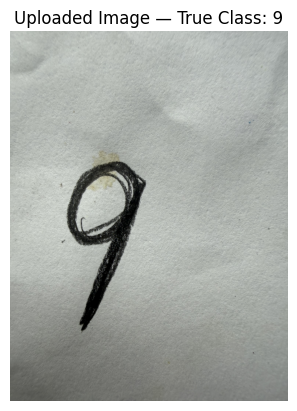

File name: IMG_4656.jpeg
Image shape: (4032, 3024, 3)


In [27]:
true_class = 9

image_9 = cv2.imread(new_file)

plt.imshow(cv2.cvtColor(image_9, cv2.COLOR_BGR2RGB))
plt.title("Uploaded Image — True Class: 9")
plt.axis("off")
plt.show()

print("File name:", new_file)
print("Image shape:", image_9.shape)

Preprocessing the New Images
The uploaded photographs are different from the MNIST images. They may be larger, colored, and written with dark ink on a light background.

Before prediction, each image is converted to grayscale, inverted when necessary, cropped around the digit, resized, centered on a 28 × 28 black background, and normalized to the range from 0 to 1.

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_digit(file_name, true_class=None, debug=False):
    image = cv2.imread(file_name)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

   # 1) Estimate the background using morphological CLOSE.
#    The kernel should be significantly larger than the thickness of the pen stroke
#    so that the stroke is completely removed from the background estimate.
#    Unlike Gaussian blur, closing fills the stroke instead of merely blurring it.
    h, w = gray.shape
    k = max(21, int(min(h, w) * 0.06))
    if k % 2 == 0:
        k += 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    background = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

    # 2) Divide the grayscale image by the estimated background
#    to reduce shadows and uneven lighting.
    normalized = cv2.divide(gray, background, scale=255)

    # 3) Apply Otsu's thresholding.
    _, binary = cv2.threshold(
        normalized, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
# Remove small amounts of noise.
    cleaned = cv2.morphologyEx(
        binary, cv2.MORPH_OPEN,
        np.ones((3, 3), np.uint8),
        iterations=1
    )
# Find the digit contours.
    contours, _ = cv2.findContours(
        cleaned, cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        raise ValueError("No contours were detected.")
# Select the largest contour.
    largest = max(contours, key=cv2.contourArea)
    x, y, w_, h_ = cv2.boundingRect(largest)
# Add padding around the detected digit.
    pad = int(0.15 * max(w_, h_))
    x0, y0 = max(0, x - pad), max(0, y - pad)
    x1 = min(cleaned.shape[1], x + w_ + pad)
    y1 = min(cleaned.shape[0], y + h_ + pad)
    digit = cleaned[y0:y1, x0:x1]

# Resize the digit while preserving its aspect ratio.
    dh, dw = digit.shape
    scale = 20 / max(dw, dh)
    new_w = max(1, int(dw * scale))
    new_h = max(1, int(dh * scale))
    digit = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

   # Center the digit on a 28 × 28 black canvas.
    mnist_image = np.zeros((28, 28), dtype=np.uint8)
    x_offset = (28 - new_w) // 2
    y_offset = (28 - new_h) // 2
    mnist_image[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = digit

# Normalize the image and prepare it for the model.
    model_input = mnist_image.astype("float32") / 255.0
    model_input = model_input.reshape(1, 28, 28, 1)

# Make the prediction.
    probabilities = model.predict(model_input, verbose=0)
    prediction = np.argmax(probabilities[0])
    confidence = np.max(probabilities[0]) * 100

    if debug:
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        axes[0].imshow(gray, cmap="gray"); axes[0].set_title("Gray"); axes[0].axis("off")
        axes[1].imshow(background, cmap="gray"); axes[1].set_title(f"Arka Plan (k={k})"); axes[1].axis("off")
        axes[2].imshow(normalized, cmap="gray"); axes[2].set_title("Düzleştirilmiş"); axes[2].axis("off")
        axes[3].imshow(cleaned, cmap="gray"); axes[3].set_title("Binary (temiz)"); axes[3].axis("off")
        axes[4].imshow(mnist_image, cmap="gray"); axes[4].set_title(f"Pred: {prediction} ({confidence:.1f}%)"); axes[4].axis("off")
        plt.show()

    plt.figure(figsize=(9, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Original — True Class: {true_class}")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(mnist_image, cmap="gray")
    plt.title(f"Prediction: {prediction}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    return prediction, confidence

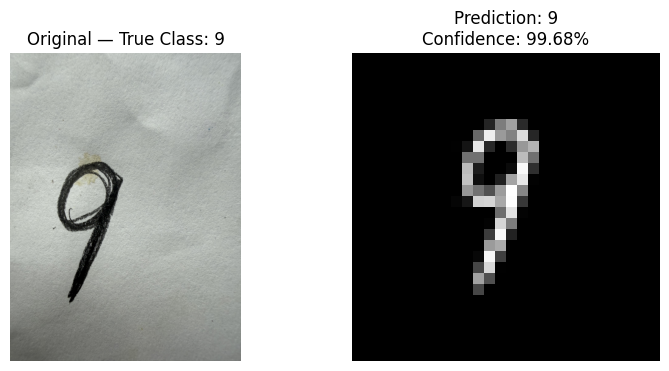

In [29]:
prediction_9, confidence_9 = predict_uploaded_digit(
    "IMG_4656.jpeg",
    true_class=9
)

The digit 9 was selected as a difficult example because its tail was not preserved clearly during preprocessing. Without this distinguishing part, the processed image looked more similar to a 0, which made the classification more difficult for the model.

In [30]:
from google.colab import files

uploaded = files.upload()
new_file = list(uploaded.keys())[0]

print("Uploaded file:", new_file)

Saving IMG_4660.jpeg to IMG_4660.jpeg
Saving IMG_4661.jpeg to IMG_4661.jpeg
Saving IMG_4662.jpeg to IMG_4662.jpeg
Saving IMG_4663.jpeg to IMG_4663.jpeg
Uploaded file: IMG_4660.jpeg


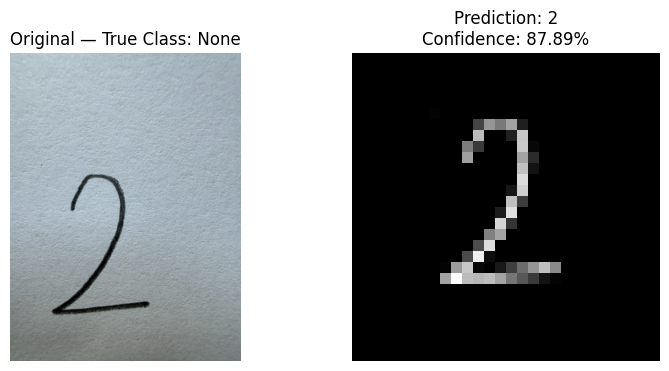

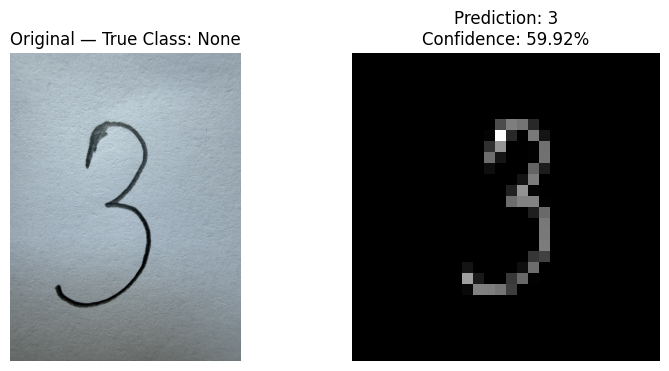

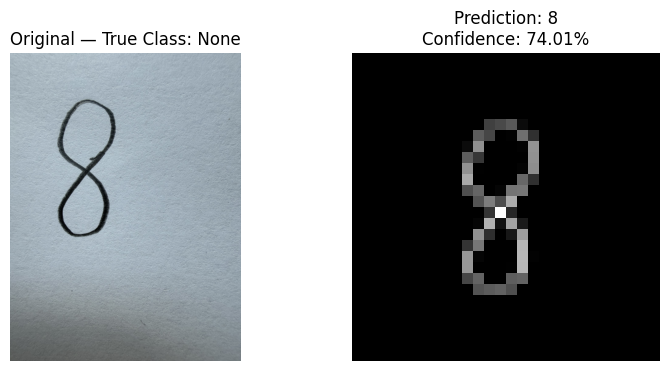

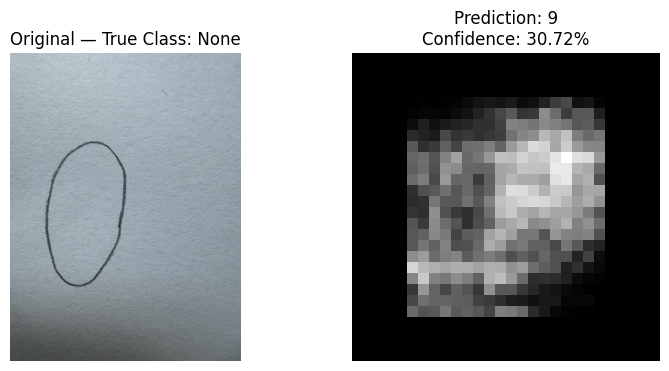

,File,Predicted Class,Confidence (%)
0,IMG_4660.jpeg,2,87.889999
1,IMG_4661.jpeg,3,59.919998
2,IMG_4662.jpeg,8,74.010002
3,IMG_4663.jpeg,9,30.719999


In [31]:
import pandas as pd

results = []

for file_name in uploaded.keys():
    prediction, confidence = predict_uploaded_digit(file_name)

    results.append({
        "File": file_name,
        "Predicted Class": prediction,
        "Confidence (%)": round(confidence, 2)
    })

results_df = pd.DataFrame(results)
display(results_df)

The digit 0 was also selected as a difficult example because the model did not recognize it correctly. Its writing style and image quality differed from the standardized MNIST examples, showing that real handwritten photographs can be more challenging than the original test dataset.

The other uploaded digits were selected as relatively easy examples because their shapes were clear and their main features remained visible after preprocessing. Their processed images were more similar to the examples found in the MNIST dataset.


### Predictions on External Images

To test the model outside the MNIST dataset, five photographs containing the handwritten digits 0, 2, 3, 8, and 9 were uploaded. These images were taken with a phone and were not included in the original training, validation, or test sets.

The photographs could not be given directly to the CNN because they contained paper texture, shadows, uneven lighting, and large background areas. The model expects a centered 28 × 28 grayscale image with a white digit on a black background.

Each photograph was therefore converted to grayscale. Morphological closing was used to estimate the paper background, and background normalization was applied to reduce shadows and lighting differences. Otsu's thresholding was then used to separate the handwriting from the paper. The detected digit was cropped, resized, centered, and converted into the same 28 × 28 format as the MNIST images.

The digits 2, 3, and 8 were relatively easy to process because their main lines were clear. The digits 0 and 9 were more challenging. The 0 was written faintly, which reduced its contrast against the paper. The tail of the 9 was also difficult to preserve during preprocessing. If this part is lost, the processed image can look similar to a 0.

The preprocessing method was adjusted to preserve the significant parts of each digit. The processed MNIST-style image was also displayed before evaluating the prediction. This made it possible to check whether an incorrect result was caused by the CNN or by information lost during preprocessing.

This experiment showed that high accuracy on the MNIST test set does not guarantee perfect performance on photographs taken in real conditions. Prediction quality also depends on lighting, handwriting style, pen color, image quality, and the preprocessing method. The results were therefore useful for understanding both the strengths and the limitations of the complete classification system.

After preprocessing, the model correctly classified the five uploaded digits. This result shows that the model can recognize external handwritten images when the digits are clearly separated and converted into an MNIST-style format. However, the preprocessing difficulties observed with some images show that the complete system may not perform equally well under every real-world condition.

## 8. Business Application

### The Problem

Public organizations may process large numbers of paper forms containing handwritten application numbers, postal codes, dates, identification numbers, or meter readings. Entering these values manually takes time and may lead to typing errors.

### The Users

The main users would be municipal employees or other public-service workers who transfer information from paper forms into digital systems. The system would support their work rather than completely replace human review.

### The Proposed Solution

The CNN model could be used as one part of a form-digitization system. A paper form would first be scanned or photographed. The system would then locate the handwritten number fields and separate the individual digits.

Each digit would be preprocessed and converted into the same 28 × 28 format used during model training. The CNN would classify the digits, and the predicted numbers would be transferred to the relevant fields in the digital system.

The proposed workflow would be:

> User scans a form → The system detects the digit fields → Each digit is preprocessed → The CNN predicts the classes → The values are transferred to the digital form → Uncertain predictions are reviewed by an employee

### The Business Value

The system could reduce repetitive manual data entry, save processing time, and decrease simple typing errors. Employees could focus on records that require attention instead of entering every value manually.

Predictions with low confidence should be sent for human review rather than accepted automatically. This would allow the organization to benefit from automation while reducing the risk of incorrect records.

This project currently represents only the digit-classification part of the proposed system. A complete application would also require form detection, digit segmentation, secure data storage, and a user interface.

## 9. Limitations and Risks

Although the model achieved 99.20% accuracy on the MNIST test set, it still has several limitations. These limitations become more important when the model is used with photographs taken under real-world conditions.

| Limitation or Risk | Possible Solution |
|---|---|
| Real photographs may contain shadows, paper texture, uneven lighting, and background noise. Colored or faint handwriting may also lose contrast when the image is converted to grayscale. | Users should take clear and closely cropped photographs with good lighting and strong contrast. A future model could also be trained with different pen colors, backgrounds, and lighting conditions. |
| During background removal, thresholding, resizing, and centering, thin parts of a digit may disappear or separate lines may become connected. The processed image may therefore look different from the original handwriting and lead to an incorrect prediction. | The processed MNIST-style image should be checked before an important prediction is accepted. More advanced preprocessing methods and human review could reduce this risk. |
| The model can classify only one digit at a time. It cannot automatically locate and separate several digits on a complete form. | A digit-detection and segmentation stage would be required before sending individual digits to the CNN. |
| The model may produce an incorrect prediction with high confidence. Confidence should therefore not be treated as a guarantee of correctness. | Important records, low-confidence results, and unusual images should be reviewed by an employee. |
| The model recognizes only the classes from 0 to 9. It cannot recognize letters, words, or connected handwriting. | A different and more diverse dataset would be required to train a system for letters or complete handwritten text. |
| Public-service forms may contain personal information. Incorrect predictions could also create incorrect digital records. | Images and predictions should be stored securely, access should be limited to authorized employees, and human review should remain part of the process. |

These limitations show why human oversight is still necessary. The model could support employees, save time, and reduce repetitive data entry, but it should not make important decisions without an appropriate review process.

### Saving the Trained Model

The final model was saved so that it can be used again without repeating the training process. The native Keras format was used as the main model file because it preserves the model architecture and trained weights. A Pickle package containing the architecture, weights, and class names was also created as an additional backup.

In [32]:
import pickle

# Save the complete model in the recommended Keras format
model.save("mnist_cnn_model.keras")

# Save the architecture, weights, and classes in a Pickle package
model_package = {
    "model_architecture": model.to_json(),
    "model_weights": model.get_weights(),
    "class_names": class_names,
    "input_shape": (28, 28, 1)
}

with open("mnist_cnn_model.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("The model was saved successfully.")
print("Keras file: mnist_cnn_model.keras")
print("Pickle file: mnist_cnn_model.pkl")

The model was saved successfully.
Keras file: mnist_cnn_model.keras
Pickle file: mnist_cnn_model.pkl


In [33]:
from google.colab import files

files.download("mnist_cnn_model.keras")
files.download("mnist_cnn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
loaded_model = tf.keras.models.load_model(
    "mnist_cnn_model.keras"
)

## 10. Conclusions

This capstone project followed the complete process of building an image classification system, from dataset exploration and image preparation to model training, evaluation, external testing, and business application.

The project used 70,000 MNIST images divided into training, validation, and test sets. A custom convolutional neural network was built instead of using a complex pretrained architecture. The model contained two convolutional and pooling blocks, followed by a dense layer, dropout, and a final softmax layer for the ten digit classes.

The final model achieved a test accuracy of 99.20%. Weighted precision, recall, and F1-score were also approximately 0.992. Out of 10,000 test images, 9,920 were classified correctly and 80 were classified incorrectly. The confusion matrix and classification report showed that performance was strong across all ten classes, although some visually similar handwriting styles were more difficult to distinguish.

Early stopping was used to monitor validation loss and reduce unnecessary training. The training curves showed that training accuracy continued to increase while validation performance became more stable. This indicated a small amount of overfitting, and restoring the best model weights helped preserve good generalization.

One of the most challenging parts of the project was testing photographs of new handwritten digits. A phone photograph is very different from an MNIST image because it may contain shadows, paper texture, uneven lighting, faint ink, and large background areas. The CNN expects a centered 28 × 28 grayscale image with a white digit on a black background. For this reason, the uploaded photographs had to be converted into an MNIST-style format before prediction.

Background estimation, lighting normalization, thresholding, contour detection, resizing, and centering were used during this conversion. This stage required careful testing because a thin or disconnected part of a digit could be lost during preprocessing. The external-image experiments showed that the quality of the complete system depends on both the CNN and the preprocessing method.

The model could be used as one part of a system for digitizing handwritten numbers on public-service forms. It could help reduce repetitive data entry and typing errors. However, a complete application would also require form detection, digit segmentation, secure data storage, and human review for uncertain or important predictions.

Overall, the project achieved strong classification performance while remaining simple enough to understand and explain. More diverse real-world training images, including different handwriting styles, pen colors, lighting conditions, and backgrounds, would be the most important improvement for future work. The project demonstrated that successful image recognition depends not only on model accuracy, but on the entire process from image collection and preprocessing to evaluation and responsible use.